#**LoL Data: Import, Exploration, & Visualizations**

### a. Pulling data from Kaggle

In [ ]:
import pandas as pd
import json
import kagglehub
from kagglehub import KaggleDatasetAdapter

#games file --csv
df_games = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "datasnaek/league-of-legends",
  "games.csv",
)

#champions file with ID#'s --json so its weird
df_champs = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
  "datasnaek/league-of-legends",
  "champion_info.json"
)

#champions file with roles --json
df_champs2 = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
  "datasnaek/league-of-legends",
  "champion_info_2.json"
)

/tmp/ipykernel_4683/1845657371.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_games = kagglehub.load_dataset(


100%|██████████| 2.98M/2.98M [00:00<00:00, 20.3MB/s]

Extracting zip of games.csv...



/tmp/ipykernel_4683/1845657371.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_champs = kagglehub.load_dataset(


Using Colab cache for faster access to the 'league-of-legends' dataset.


/tmp/ipykernel_4683/1845657371.py:21: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_champs2 = kagglehub.load_dataset(


Using Colab cache for faster access to the 'league-of-legends' dataset.


In [ ]:
print("GAMES.CSV -> stored in dataframe 'df_games'\n\nCOLUMN LABELS:\n",df_games.columns,"\n\n","~"*50)

print("\nFIRST 5:\n",df_games.head())

GAMES.CSV -> stored in dataframe 'df_games'

COLUMN LABELS:
 Index(['gameId', 'creationTime', 'gameDuration', 'seasonId', 'winner',
       'firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron',
       'firstDragon', 'firstRiftHerald', 't1_champ1id', 't1_champ1_sum1',
       't1_champ1_sum2', 't1_champ2id', 't1_champ2_sum1', 't1_champ2_sum2',
       't1_champ3id', 't1_champ3_sum1', 't1_champ3_sum2', 't1_champ4id',
       't1_champ4_sum1', 't1_champ4_sum2', 't1_champ5id', 't1_champ5_sum1',
       't1_champ5_sum2', 't1_towerKills', 't1_inhibitorKills', 't1_baronKills',
       't1_dragonKills', 't1_riftHeraldKills', 't1_ban1', 't1_ban2', 't1_ban3',
       't1_ban4', 't1_ban5', 't2_champ1id', 't2_champ1_sum1', 't2_champ1_sum2',
       't2_champ2id', 't2_champ2_sum1', 't2_champ2_sum2', 't2_champ3id',
       't2_champ3_sum1', 't2_champ3_sum2', 't2_champ4id', 't2_champ4_sum1',
       't2_champ4_sum2', 't2_champ5id', 't2_champ5_sum1', 't2_champ5_sum2',
       't2_towerKills', 't2_inhibitor

In [ ]:
print("CHAMPION_INFO.JSON -> stored in dataframe 'df_champs'\n\nFIRST 5:",df_champs.head())

CHAMPION_INFO.JSON -> stored in dataframe 'df_champs'

FIRST 5:        type version                                               data
1  champion  7.17.2  {'title': 'the Dark Child', 'id': 1, 'key': 'A...
2  champion  7.17.2  {'title': 'the Berserker', 'id': 2, 'key': 'Ol...
3  champion  7.17.2  {'title': 'the Colossus', 'id': 3, 'key': 'Gal...
4  champion  7.17.2  {'title': 'the Card Master', 'id': 4, 'key': '...
5  champion  7.17.2  {'title': 'the Seneschal of Demacia', 'id': 5,...


### b. Restructuring + Win%/Usage Calculation

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# maps champion IDs to their names from df_champs
champ_dict = {}
for item in df_champs['data']:
  champ_id = item.get('id')
  champ_name = item.get('name', item.get('key', str(champ_id)))
  champ_dict[champ_id] = champ_name

#reshape and extract champions, if they won
t1_cols = [f't1_champ{i}id' for i in range(1, 6)]
t1_df = df_games[['winner'] + t1_cols].copy()
t1_df['win'] = (t1_df['winner'] == 1).astype(int)
t1_melt = t1_df.melt(id_vars=['win'], value_vars=t1_cols, value_name='champ_id')
# team 2
t2_cols = [f't2_champ{i}id' for i in range(1, 6)]
t2_df = df_games[['winner'] + t2_cols].copy()
t2_df['win'] = (t2_df['winner'] == 2).astype(int)
t2_melt = t2_df.melt(id_vars=['win'], value_vars=t2_cols, value_name='champ_id')

# combine
df_picks = pd.concat([t1_melt[['champ_id', 'win']], t2_melt[['champ_id', 'win']]])
df_picks['champ_name'] = df_picks['champ_id'].map(champ_dict)

# win-rate/pick-count calc
champ_stats = df_picks.groupby('champ_name').agg(
    picks=('win', 'count'),
    wins=('win', 'sum')
).reset_index()

champ_stats['win_rate'] = champ_stats['wins'] / champ_stats['picks']

display(champ_stats.sort_values('picks', ascending=False))

,champ_name,picks,wins,win_rate
110,Thresh,13002,6143,0.472466
111,Tristana,12983,6713,0.517061
119,Vayne,10658,5498,0.515857
53,Kayn,9853,4807,0.487872
60,Lee Sin,9188,4217,0.458968
...,...,...,...,...
92,Ryze,1032,421,0.407946
49,Karthus,1007,514,0.510427
8,Aurelion Sol,841,442,0.525565
0,Aatrox,753,354,0.470120


### c. Basic Visualizations

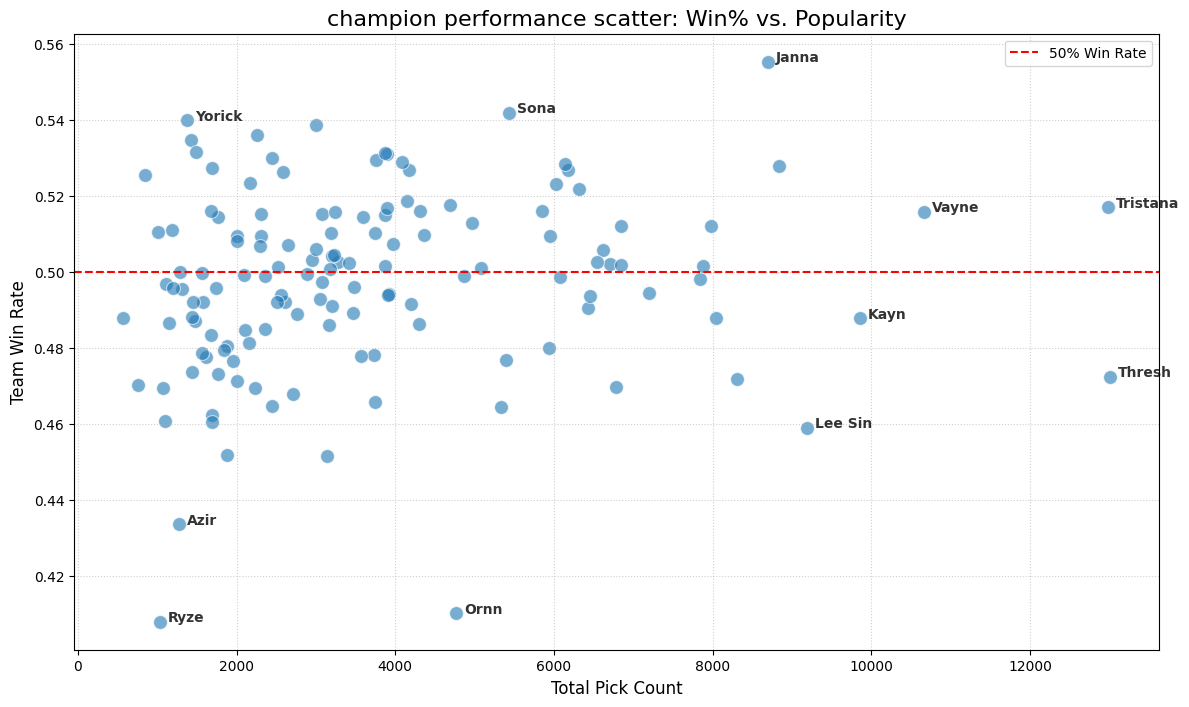

In [ ]:
plt.figure(figsize=(14, 8))

sns.scatterplot(x='picks', y='win_rate', data=champ_stats, alpha=0.6, s=100)

plt.axhline(0.5, color='red', linestyle='--', label='50% Win Rate')

top_usage = champ_stats.nlargest(5, 'picks')
top_win = champ_stats.nlargest(3, 'win_rate')
low_win = champ_stats.nsmallest(3, 'win_rate')

outliers = pd.concat([top_usage, top_win, low_win]).drop_duplicates()

for i, row in outliers.iterrows():
    plt.text(row['picks']+100, row['win_rate'], row['champ_name'],
             fontsize=10, fontweight='semibold', alpha=0.8)

plt.title('champion performance scatter: Win% vs. Popularity', fontsize=16)
plt.xlabel('Total Pick Count', fontsize=12)
plt.ylabel('Team Win Rate', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

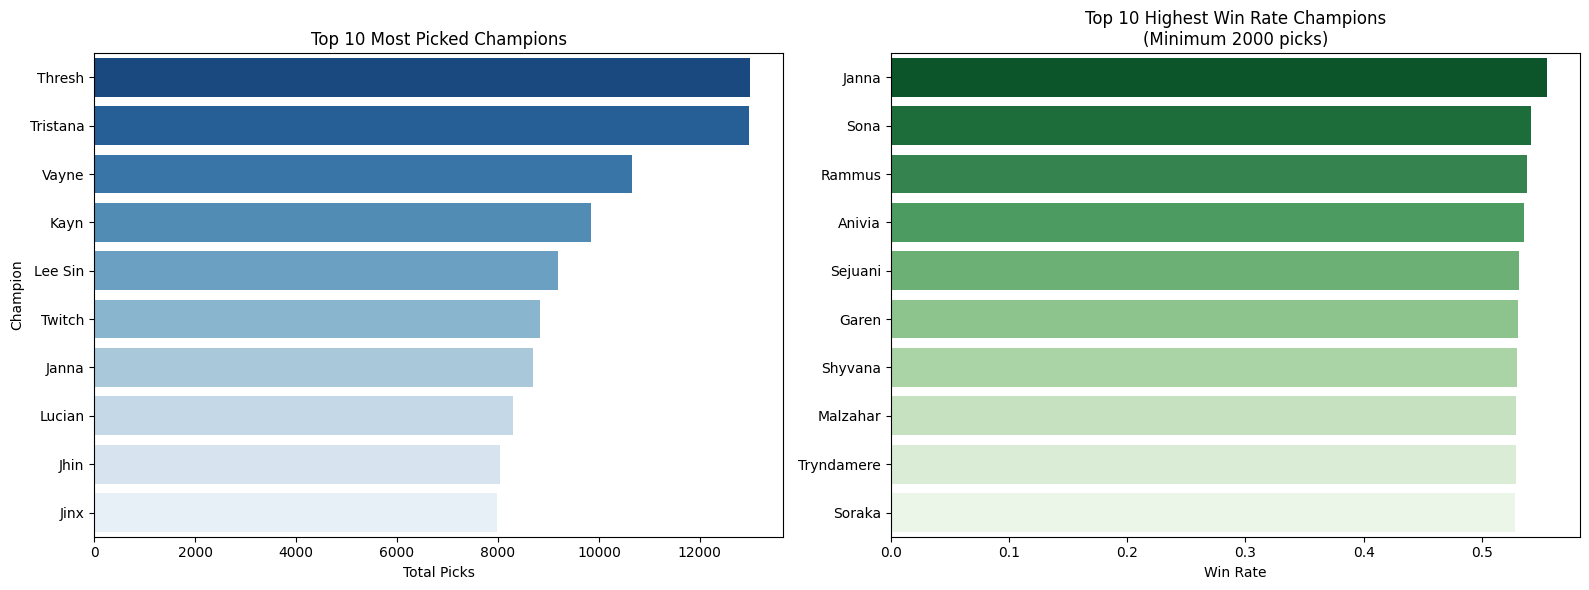

In [ ]:
top_picks = champ_stats.sort_values('picks', ascending=False).head(10)

min_picks = 2000 #arbitrary threshold?
top_winrate = champ_stats[champ_stats['picks'] >= min_picks].sort_values('win_rate', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# most picked plot
sns.barplot(x='picks', y='champ_name', data=top_picks, ax=axes[0], palette='Blues_r', hue='champ_name', legend=False)
axes[0].set_title('Top 10 Most Picked Champions')
axes[0].set_xlabel('Total Picks')
axes[0].set_ylabel('Champion')

# win rate plot
sns.barplot(x='win_rate', y='champ_name', data=top_winrate, ax=axes[1], palette='Greens_r', hue='champ_name', legend=False)
axes[1].set_title(f'Top 10 Highest Win Rate Champions\n(Minimum {int(min_picks)} picks)')
axes[1].set_xlabel('Win Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

### d. Creating a Champion Presence Dataset for Modeling

In [ ]:
import ast

# maps champion IDs to their names from df_champs
champ_dict = {}
for item in df_champs['data']:
  # Using ast.literal_eval to parse the string representation of dictionary
  # if 'data' column contains string representation of dicts
  # Otherwise, if it's already a dict, just use it directly.
  if isinstance(item, str):
      try:
          item_dict = ast.literal_eval(item)
      except (ValueError, SyntaxError):
          # Handle cases where it's not a valid dict string, e.g., skip or log
          continue # Skip this item if it's malformed
  else:
      item_dict = item

  champ_id = item_dict.get('id')
  champ_name = item_dict.get('name', item_dict.get('key', str(champ_id)))
  if champ_id is not None: # Ensure champ_id is valid before adding
      champ_dict[champ_id] = champ_name


# We need the unique champion IDs to use as features.
all_champ_ids = sorted(list(champ_dict.keys()))

# Prepare a list of dictionaries, where each dictionary represents a game
game_features = []

# Iterate through each game in the original dataframe
for index, row in df_games.iterrows():
    # Initialize a dictionary for the current game with all champions set to 0 (not present)
    game_dict = {champ_id: 0 for champ_id in all_champ_ids}

    # Mark champions present in Team 1 with a value of 1
    for i in range(1, 6):
        champ_id = row[f't1_champ{i}id']
        if champ_id in game_dict: # Ensure the champion ID is valid
            game_dict[champ_id] = 1

    # Mark champions present in Team 2 with a value of -1
    for i in range(1, 6):
        champ_id = row[f't2_champ{i}id']
        if champ_id in game_dict: # Ensure the champion ID is valid
            game_dict[champ_id] = -1

    # Add the 'winner' for the current game as the target variable
    game_dict['winner'] = row['winner']

    # Append the game's feature dictionary to our list
    game_features.append(game_dict)

# Create the new DataFrame from the list of game feature dictionaries
df_champion_presence = pd.DataFrame(game_features)

# Display information about the newly created DataFrame
print("Shape of the new DataFrame (rows, columns):", df_champion_presence.shape)
print("\nFirst 5 rows of the new DataFrame:")
# display(df_champion_presence.head())
display(df_champion_presence)
print("\nColumns of the new DataFrame (first 10 champion IDs and 'winner'):")
print(df_champion_presence.columns[:10].tolist() + ['winner'])

Shape of the new DataFrame (rows, columns): (51490, 139)

First 5 rows of the new DataFrame:


,1,2,3,4,5,6,7,8,9,10,...,412,420,421,427,429,432,497,498,516,winner
0,0,0,0,0,0,0,0,1,0,0,...,-1,0,0,0,0,1,0,-1,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,-1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,-1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,2
51486,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,-1,0,0,0,0,2
51487,-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2
51488,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2



Columns of the new DataFrame (first 10 champion IDs and 'winner'):
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'winner']


In [ ]:
# Random Forest Classifier

X = df_champion_presence.drop('winner', axis=1)
y = df_champion_presence['winner']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0) # stratify ensures an equal ratio of each target
print('Train\t',X_train.shape)
print('Test\t',X_test.shape)

Train	 (38617, 138)
Test	 (12873, 138)


In [ ]:
# These functions visualize results from a parameter grid search.

def make_grid_plot_labels(grid_clf):
  # Turns a parameter dictionary entry into a single string and returns the whole list
  res = grid_clf.cv_results_
  NUM_KEYS = len(res['params'][0].values())
  labels = []
  for item in res['params']:
    labels.append("_".join( [str(val) for val in item.values()]))
  return labels

def make_grid_plot(grid_clf):
  # Displays the scores for every set of parameters
  res = grid_clf.cv_results_
  plt.figure(figsize=(8,4))
  plt.axvline(grid_clf.best_index_, color='black', lw=2) # draw black line behind best params

  NUM_KEYS = len(res['params'])
  x = np.arange(NUM_KEYS)
  plt.plot(res['mean_test_score'],'-o', label='Val')
  plt.fill_between(x,res['mean_test_score']+res['std_test_score'], res['mean_test_score']-res['std_test_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_test_score'],yerr=res['std_test_score'],xerr=0,fmt='-o', capsize=2, label='Val')

  plt.plot(res['mean_train_score'],'-s', label='Train')
  plt.fill_between(x,res['mean_train_score']+res['std_train_score'], res['mean_train_score']-res['std_train_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_train_score'],yerr=res['std_train_score'],xerr=0,fmt='-s', capsize=2,label='Train')
  plt.title('Grid CV Results')
  plt.ylabel('Mean Test Score')

  labels = make_grid_plot_labels(grid_clf)
  plt.xticks(ticks = x, labels=labels, rotation=90)
  plt.legend()
  plt.grid()
  plt.show()

In [ ]:
KLIST = np.arange(1,16)
WLIST = ['uniform']
#WLIST = ['distance']
#WLIST = ['uniform','distance']  # doing both makes this plot messy
params = {'clf__n_neighbors':KLIST, 'clf__weights':WLIST}
print('Grid Parameters:',params)

grid_clf = GridSearchCV(estimator,param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

make_grid_plot(grid_clf)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")

Grid Parameters: {'clf__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]), 'clf__weights': ['uniform']}


NameError: name 'estimator' is not defined

###HistogramGradientBoost

In [ ]:
estimators = [('clf', HistGradientBoostingClassifier(max_iter=200, early_stopping=True, random_state=0)) ]

pipe = Pipeline(estimators)
pipe.fit(X_train,y_train)
print('n_estimators asked:  ', pipe[-1].max_iter)
print('n_estimators used:   ', pipe[-1].n_iter_)
print('max val score n_iter=',pipe[-1].validation_score_.argmax())

plt.figure(figsize=(10,3))
plt.plot(pipe[-1].validation_score_,label='Validation')
plt.plot(pipe[-1].train_score_,label='Train')
plt.legend()
plt.title('Learning Curve')
plt.xlabel('n_iter')
plt.ylabel('Loss')
plt.grid()
plt.show()

NameError: name 'Pipeline' is not defined

In [ ]:
hgb_model = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=6, random_state=42)
hgb_model.fit(X_train, y_train)

y_pred = hgb_model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Team 2 Wins', 'Team 1 Wins']))


Test Accuracy: 0.5414

Classification Report:
              precision    recall  f1-score   support

 Team 2 Wins       0.54      0.58      0.56      6520
 Team 1 Wins       0.54      0.50      0.52      6353

    accuracy                           0.54     12873
   macro avg       0.54      0.54      0.54     12873
weighted avg       0.54      0.54      0.54     12873



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Neural Network model
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=1500,
    random_state=42
)

# Train the model
nn_model.fit(X_train, y_train)

# Predict
y_pred = nn_model.predict(X_test)

# Evaluate
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Team 2 Wins', 'Team 1 Wins']))

Test Accuracy: 0.5191

Classification Report:
              precision    recall  f1-score   support

 Team 2 Wins       0.53      0.53      0.53      5231
 Team 1 Wins       0.51      0.50      0.51      5067

    accuracy                           0.52     10298
   macro avg       0.52      0.52      0.52     10298
weighted avg       0.52      0.52      0.52     10298

